In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data Processing

This notebook was made after the fraud classificaiton notebook, meaning some of the data processing steps will not be redone.

In [2]:
pd.set_option("display.max_columns", None)
insurance_claims = pd.read_csv('insurance_claims.csv')

print(insurance_claims.shape, '\n')
insurance_claims.head()

(1000, 40) 



,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
# removing unnecessary columns for regression
insurance_claims = insurance_claims.drop(columns = ['policy_number', 'policy_state', 'insured_hobbies', 'incident_state', 'incident_city', 
                                                    'incident_location', '_c39', 'insured_occupation', 'auto_model', 'insured_zip', 'injury_claim', 
                                                    'property_claim', 'vehicle_claim', 'fraud_reported', 'incident_date', 'policy_bind_date'])

In [4]:
# replacing '?' entires
insurance_claims[['police_report_available', 'collision_type', 'property_damage']] = insurance_claims[['police_report_available', 'collision_type', 'property_damage']].replace("?", "NO")
insurance_claims['authorities_contacted'] = insurance_claims['authorities_contacted'].fillna('No')

In [5]:
# checking number of unique entries
insurance_claims.nunique()

months_as_customer             391
age                             46
policy_csl                       3
policy_deductable                3
policy_annual_premium          991
umbrella_limit                  11
insured_sex                      2
insured_education_level          7
insured_relationship             6
capital-gains                  338
capital-loss                   354
incident_type                    4
collision_type                   4
incident_severity                4
authorities_contacted            5
incident_hour_of_the_day        24
number_of_vehicles_involved      4
property_damage                  2
bodily_injuries                  3
witnesses                        4
police_report_available          2
total_claim_amount             763
auto_make                       14
auto_year                       21
dtype: int64

## Numeric Features

Both `months_as_customer` and `age` should be relevant for insurance pricing, but due to the high correlation, the `months_as_customer` column was removed.

Looking at the histogram, the distribution is mostly centred around $ 60,000 $, but there is a large group of smaller claims around $ 5,000 $ that make up their own cluster. This may cause the machine learning models to focus on predicting those two values, while struggling to predict the in-between claims.

Correlation analysis shows that `incident_hour_of_the_day` and `number_of_vehicles_involved` have a slight correlation with the `total_claim_amount`, with the rest of the features having no correlation.

The ANOVA results show that the features `incident_hour_of_the_day` and `number_of_vehicles_involved` are statistically significant at $\alpha = 0.05$, suggesting the groups have variations in the total claim amount. This aligns with the correlation analysis. 

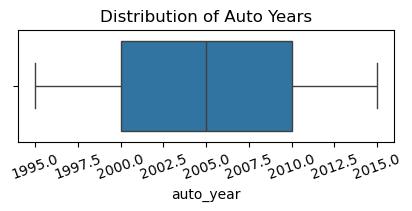

In [6]:
insurance_claims = insurance_claims[insurance_claims['umbrella_limit'] >= 0]

numeric = insurance_claims.select_dtypes(include = ['int64', 'float64'])
numeric = numeric.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 11]]

plt.figure(figsize = (4, 2), constrained_layout = True)

sns.boxplot(x = numeric['auto_year'])
plt.title('Distribution of Auto Years')
plt.xticks(rotation = 20)

plt.show()

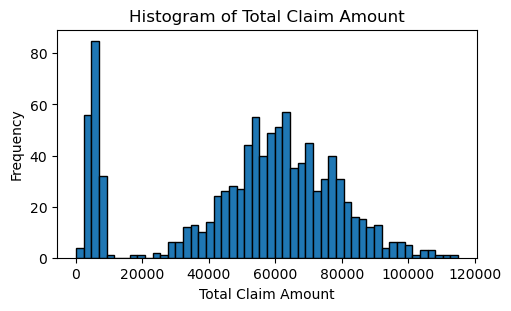

In [46]:
plt.figure(figsize = (5, 3), constrained_layout = True)

plt.hist(numeric['total_claim_amount'], bins = 50, edgecolor = 'black')
plt.title('Histogram of Total Claim Amount')
plt.xlabel('Total Claim Amount')
plt.ylabel('Frequency')

plt.show()

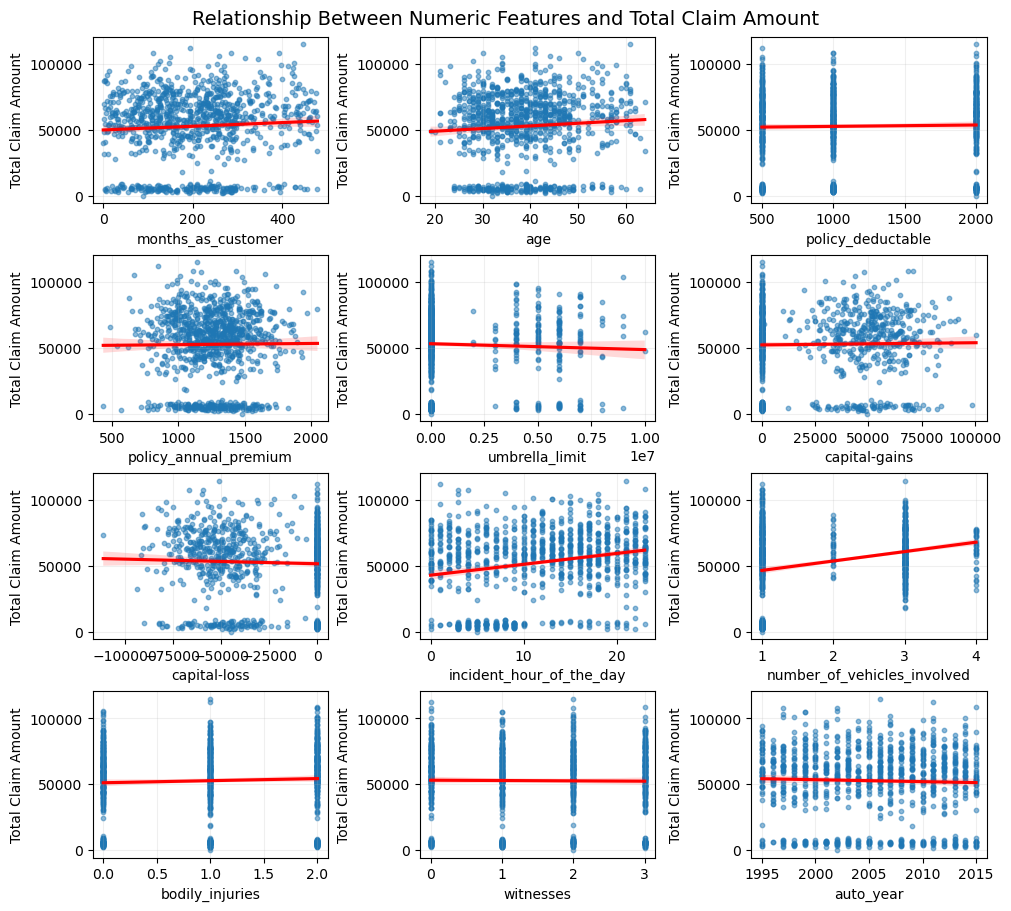

In [8]:
fig, axes = plt.subplots(4, 3, figsize = (10, 9), constrained_layout = True)
axes = axes.flatten()
plt.suptitle('Relationship Between Numeric Features and Total Claim Amount', fontsize = 14)

for i, col in enumerate(numeric.columns):
    if col == 'total_claim_amount':
        continue
    sns.regplot(x = numeric[col], y = numeric['total_claim_amount'], ax = axes[i], scatter_kws = {'s': 10, 'alpha': 0.5}, line_kws = {'color': 'red'})
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Total Claim Amount')
    axes[i].grid(alpha = 0.2)
    
plt.show()

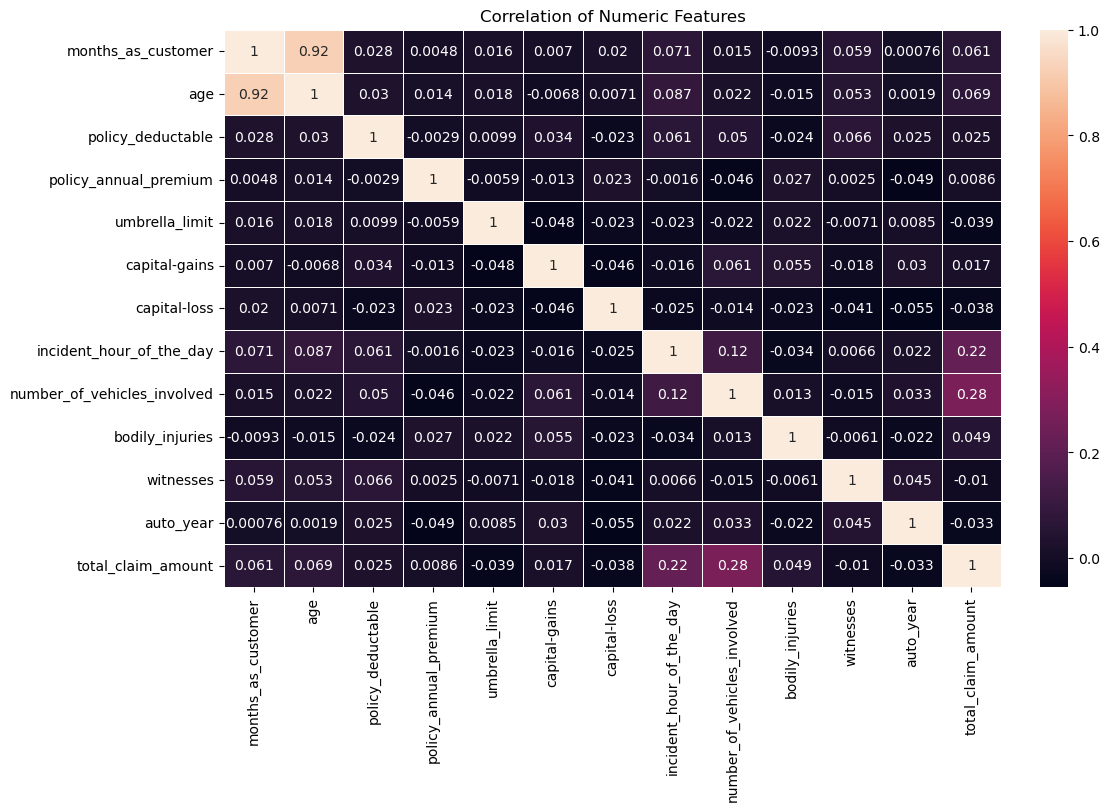

In [9]:
numeric_corr = numeric.corr()

plt.figure(figsize = (11, 8), constrained_layout = True)

sns.heatmap(numeric_corr, annot = True, fmt = '.2g', linewidths = 0.5)
plt.title('Correlation of Numeric Features')

plt.show()

In [10]:
numeric = numeric.drop(columns = ['months_as_customer'])

In [11]:
anova_scores = {}

for col in numeric:
    if insurance_claims[col].nunique() > 25:
        continue
        
    groups = numeric['total_claim_amount'].groupby(numeric[col])
    f_stat, p_value = stats.f_oneway(*[group for _, group in groups])
    anova_scores[col] = (f_stat, p_value, p_value < 0.05)

anova_scores_df = pd.DataFrame.from_dict(anova_scores, orient = 'index', columns = ['f_stat', 'p_value', 'significant'])
anova_scores_df

,f_stat,p_value,significant
policy_deductable,0.672520,5.106522e-01,False
umbrella_limit,0.569426,8.228614e-01,False
incident_hour_of_the_day,8.255025,2.040974e-25,True
number_of_vehicles_involved,29.970181,1.491532e-18,True
bodily_injuries,2.592806,7.531473e-02,False
witnesses,1.413486,2.373220e-01,False
auto_year,0.942666,5.319111e-01,False


## Categorical Features

The mean total claim amount across the features is roughly equal apart from `incident_type`, `collision_type`, `incident_severity`, and `authorities_contacted`. Those features have categories that are substantially lower in mean total claim cost.

Looking at the ANOVA results, the features `incident_type`, `collision_type`, `incident_severity`, and `authorities_contacted` are statistically significant at $\alpha = 0.05$, suggesting the groups have variations in the total claim amount. This is consistent with patterns in the bar charts. 

Initially, the `auto_make` column was kept, as car brands were expected to have a strong impact on the total claim amount. However, the ANOVA test showed no significance and the mean values across subfeautres are very similar. Further, one-hot encoding would add 14 dimensions, which is likely to introduce a lot of noise than to improve model performance, so the column was removed.

In [12]:
categorical = insurance_claims.select_dtypes(include = ['object'])
categorical['total_claim_amount'] = insurance_claims['total_claim_amount']

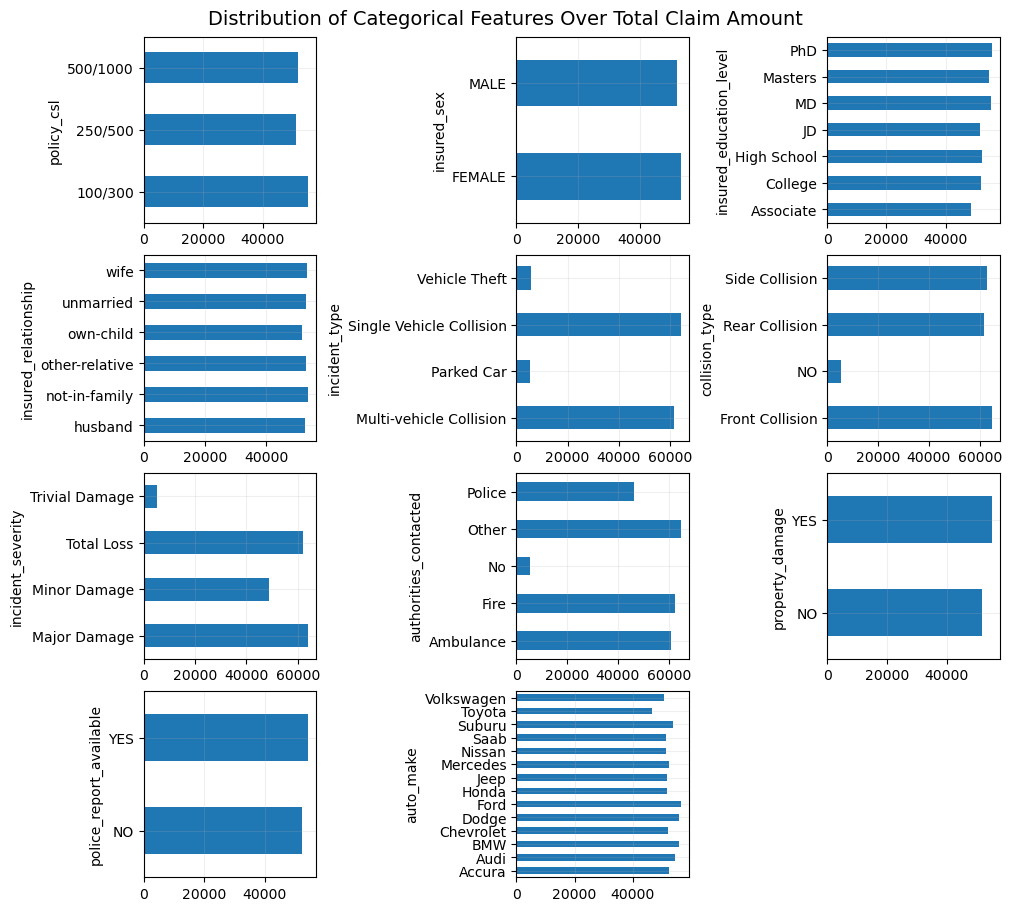

In [13]:
fig, axes = plt.subplots(4, 3, figsize = (10, 9), constrained_layout = True)
axes = axes.flatten()
plt.suptitle('Distribution of Categorical Features Over Total Claim Amount', fontsize = 14)

for i in range(len(categorical.columns)):
    categorical.groupby(categorical.columns[i])['total_claim_amount'].mean().plot(kind = 'barh', ax = axes[i])
    axes[i].grid(alpha = 0.2)

axes[11].set_visible(False)

plt.show()

In [14]:
anova_scores = {}

for col in categorical:
    if insurance_claims[col].nunique() > 25:
        continue
        
    groups = categorical['total_claim_amount'].groupby(categorical[col])
    f_stat, p_value = stats.f_oneway(*[group for _, group in groups])
    anova_scores[col] = (f_stat, p_value, p_value < 0.05)

anova_scores_df = pd.DataFrame.from_dict(anova_scores, orient = 'index', columns = ['f_stat', 'p_value', 'significant'])
anova_scores_df

,f_stat,p_value,significant
policy_csl,2.316498,9.914943e-02,False
insured_sex,0.646903,4.214139e-01,False
insured_education_level,1.229270,2.885661e-01,False
insured_relationship,0.135872,9.840401e-01,False
incident_type,773.434129,1.908066e-259,True
collision_type,771.666211,4.230311e-259,True
incident_severity,207.734726,1.310926e-104,True
authorities_contacted,167.629027,1.058125e-109,True
property_damage,3.405967,6.525741e-02,False
police_report_available,1.381727,2.400879e-01,False


In [15]:
categorical = categorical.drop(columns = ['total_claim_amount', 'auto_make'])

# Modelling

In [16]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoding = ['policy_csl', 'insured_education_level', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 
                    'authorities_contacted']#, 'auto_make']
binary_encoding = ['insured_sex', 'property_damage', 'police_report_available']

categorical['insured_sex'] = categorical['insured_sex'].map({'FEMALE': 0, 'MALE': 1})
categorical['property_damage'] = categorical['property_damage'].map({'NO': 0, 'YES': 1})
categorical['police_report_available'] = categorical['police_report_available'].map({'NO': 0, 'YES': 1})

encoder = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')
one_hot = encoder.fit_transform(categorical[one_hot_encoding])
categorical = pd.concat([categorical.drop(columns = one_hot_encoding), one_hot], axis = 1)

In [17]:
numeric_columns = numeric.columns.drop('total_claim_amount')
claims_forecasting_data = pd.concat([categorical, numeric], axis = 1)
claims_forecasting_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   insured_sex                             999 non-null    int64  
 1   property_damage                         999 non-null    int64  
 2   police_report_available                 999 non-null    int64  
 3   policy_csl_100/300                      999 non-null    float64
 4   policy_csl_250/500                      999 non-null    float64
 5   policy_csl_500/1000                     999 non-null    float64
 6   insured_education_level_Associate       999 non-null    float64
 7   insured_education_level_College         999 non-null    float64
 8   insured_education_level_High School     999 non-null    float64
 9   insured_education_level_JD              999 non-null    float64
 10  insured_education_level_MD              999 non-null    float64
 11

In [18]:
from sklearn.model_selection import train_test_split

x = claims_forecasting_data.drop(columns = ['total_claim_amount'])
y = claims_forecasting_data['total_claim_amount']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
all_columns = x_train.columns

## Linear Regression

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

preprocessor = ColumnTransformer(
    transformers = [
        ('numeric_scaled', StandardScaler(), numeric_columns)
    ], 
    remainder = 'passthrough'
)

pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor), 
        ('model', LinearRegression())
    ]
)

lr = TransformedTargetRegressor(
    regressor = pipeline, 
    func = np.log1p, 
    inverse_func = np.expm1
)

In [20]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

lr.fit(x_train, y_train)

def regression_results(model, x_train = x_train, y_train = y_train, x_test = x_test, y_test = y_test):
    y_train_prediction = model.predict(x_train)

    print('TRAINING METRICS')
    print(f'RMSE: {root_mean_squared_error(y_train, y_train_prediction):.0f}')
    print(f'MAE: {mean_absolute_error(y_train, y_train_prediction):.0f}')
    print(f'R^2: {r2_score(y_train, y_train_prediction):.3f}')

    y_test_prediction = model.predict(x_test)
    
    results = {
        'rmse': root_mean_squared_error(y_test, y_test_prediction),
        'mae': mean_absolute_error(y_test, y_test_prediction),
        'r2': r2_score(y_test, y_test_prediction),
        'y_pred': y_test_prediction,
    }

    print('TESTING METRICS')
    print(f'RMSE: {results['rmse']:.0f}')
    print(f'MAE: {results['mae']:.0f}')
    print(f'R^2: {results['r2']:.3f}')

    return results

lr_results = regression_results(lr)

TRAINING METRICS
RMSE: 14257
MAE: 10519
R^2: 0.705
TESTING METRICS
RMSE: 14343
MAE: 10717
R^2: 0.714


## Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor), 
        ('model', RandomForestRegressor())
    ]
)

rfr = TransformedTargetRegressor(
    regressor = pipeline, 
    func = np.log1p, 
    inverse_func = np.expm1
)

In [22]:
rfr.fit(x_train, y_train)

_ = regression_results(rfr)

TRAINING METRICS
RMSE: 5987
MAE: 4192
R^2: 0.948
TESTING METRICS
RMSE: 14414
MAE: 10554
R^2: 0.711


In [23]:
from sklearn.model_selection import RandomizedSearchCV

parameters = {
    'regressor__model__n_estimators': [100, 200, 300], 
    'regressor__model__min_samples_split': [2, 3, 4],
    'regressor__model__min_samples_leaf': [1, 2, 3], 
    'regressor__model__max_depth': [3, 4, 5], 
    'regressor__model__max_features': ['sqrt', 'log2', 0.5, 0.8]
}

rfr_rs = RandomizedSearchCV(rfr, parameters, n_iter = 50, cv = 5, scoring = 'neg_root_mean_squared_error', random_state = 42, n_jobs = -1)
rfr_rs.fit(x_train, y_train)
best_rfr = rfr_rs.best_estimator_

print('Best Parameters:', rfr_rs.best_params_, '\n')

rfr_results = regression_results(best_rfr)

Best Parameters: {'regressor__model__n_estimators': 300, 'regressor__model__min_samples_split': 2, 'regressor__model__min_samples_leaf': 3, 'regressor__model__max_features': 0.8, 'regressor__model__max_depth': 3} 

TRAINING METRICS
RMSE: 14329
MAE: 10482
R^2: 0.702
TESTING METRICS
RMSE: 14218
MAE: 10457
R^2: 0.719


## Gradient Boosting Regressor

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor), 
        ('model', GradientBoostingRegressor(n_iter_no_change = 10))
    ]
)

gbr = TransformedTargetRegressor(
    regressor = pipeline, 
    func = np.log1p, 
    inverse_func = np.expm1
)

In [25]:
gbr.fit(x_train, y_train)

_ = regression_results(gbr)

TRAINING METRICS
RMSE: 13111
MAE: 9532
R^2: 0.751
TESTING METRICS
RMSE: 14427
MAE: 10747
R^2: 0.710


In [26]:
parameters = {
    'regressor__model__learning_rate': [0.01, 0.1, 0.2],
    'regressor__model__n_estimators': [100, 200, 300],
    'regressor__model__max_depth': [3, 4, 5],
    'regressor__model__min_samples_split': [2, 3, 4],
    'regressor__model__min_samples_leaf': [1, 2, 3]
}

gbr_rs = RandomizedSearchCV(gbr, parameters, n_iter = 50, cv = 5, scoring = 'neg_root_mean_squared_error', random_state = 42, n_jobs = -1)
gbr_rs.fit(x_train, y_train)
best_gbr = gbr_rs.best_estimator_

print('Best Parameters:', gbr_rs.best_params_, '\n')

gbr_results = regression_results(best_gbr)

Best Parameters: {'regressor__model__n_estimators': 100, 'regressor__model__min_samples_split': 3, 'regressor__model__min_samples_leaf': 2, 'regressor__model__max_depth': 3, 'regressor__model__learning_rate': 0.1} 

TRAINING METRICS
RMSE: 13757
MAE: 9946
R^2: 0.726
TESTING METRICS
RMSE: 14130
MAE: 10448
R^2: 0.722


# Analysis

GBR performs the best across all metrics, with the lowest RMSE and MAE, and the highest $R^{2}$. LR performs the worst across all metrics, with RFR sitting in between. Despite this, the differences between the models are not very large, suggesting that each model struggles to understand the patterns in the data.

The increasing regression line indicates that the model captures the general relationship between smaller (0–10) and larger (30–100) claims. However, the predictions are concentrated within a narrow range, suggesting the models do not fully capture the underlying patterns and instead minimise loss by regressing toward the mean. This issue may stem from the data itself, as lower claims are clustered around 5, which the models predict accurately, while higher claims are heavily concentrated between 50–70, aligning with the range of the models’ predictions. RFR does have a narrower, higher claim prediction at around 55-65. The snapshot of model predictions reinforces the regression plot, showing that predictions are clustered around 5 for lower claims and 60 for higher claims.

The feature importance analysis shows that across each model, `authorities_contacted_Police` is the most important feature by a large margin. This reinforces the hypothesis testing results, which showed `authorities_contacted` to be highly significant. GBR seems to rely on this single feature, suggesting most of the patterns are captured from it. In contrast, LR spreads importance across several variables, with many of the strongest predictors being subfeatures of `authorities_contacted`.

A potentially improved approach to this problem is to create separate models for the two clusters, which would allow the models to better capture patterns within their respective range. In practice, this would require a classifier to first assign the data to the correct group, followed by the corresponding regression model. A classifier is likely to be effective since the regression models are already able to differentiate between the two classes. 

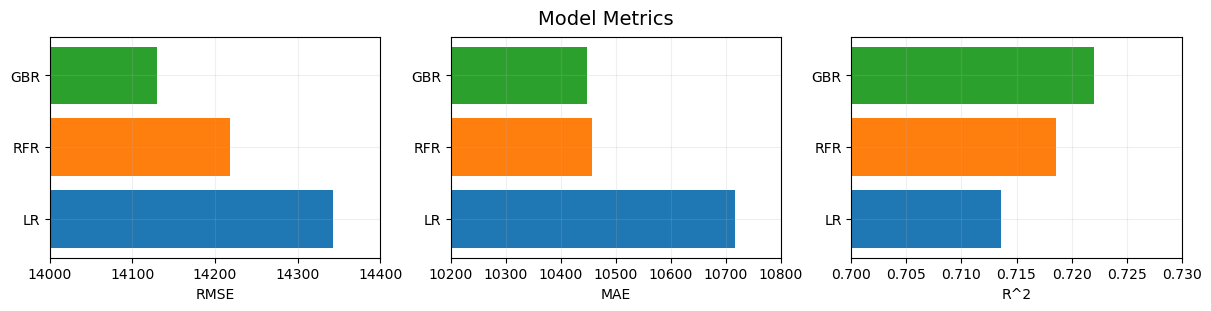

In [45]:
model_results = {
    'RMSE': {'LR': lr_results['rmse'], 'RFR': rfr_results['rmse'], 'GBR': gbr_results['rmse']}, 
    'MAE': {'LR': lr_results['mae'], 'RFR': rfr_results['mae'], 'GBR': gbr_results['mae']}, 
    'R^2': {'LR': lr_results['r2'], 'RFR': rfr_results['r2'], 'GBR': gbr_results['r2']}
}

fig, axes = plt.subplots(1, 3, figsize = (12, 3), constrained_layout = True)
axes = axes.flatten()
plt.suptitle('Model Metrics', fontsize = 14)

for i, single_result in enumerate(model_results.items()):
    for name, findings in single_result[1].items():
        axes[i].barh(name, findings)
        axes[i].set_xlabel(single_result[0])
        axes[i].grid(alpha = 0.2)

        if single_result[0] == 'RMSE':
            axes[i].set_xlim(14000, 14400)
        elif single_result[0] == 'MAE':
            axes[i].set_xlim(10200, 10800)
        elif single_result[0] == 'R^2':
            axes[i].set_xlim(0.7, 0.73)

plt.show()

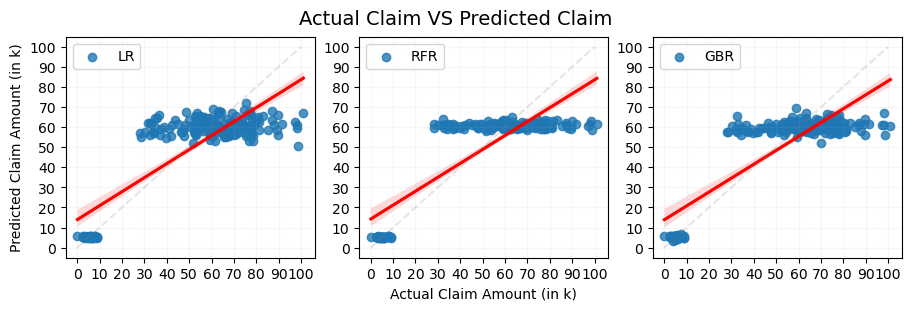

In [47]:
model_predictions = {
    'LR': (lr_results['y_pred'], 'blue', 0.75),
    'RFR': (rfr_results['y_pred'], 'red', 0.75),
    'GBR': (gbr_results['y_pred'], 'green', 0.75)
}

fig, axes = plt.subplots(1, 3, figsize = (9, 3), constrained_layout = True)
axes = axes.flatten()
plt.suptitle('Actual Claim VS Predicted Claim', fontsize = 14)

for i, dict_return in enumerate(model_predictions.items()):
    sns.regplot(x = y_test, y = dict_return[1][0], ax = axes[i], line_kws = {'color': 'red'}, label = dict_return[0])
    #axes[i].scatter(y_test, dict_return[1][0], label = dict_return[0], color = dict_return[1][1], alpha = dict_return[1][2])
    axes[i].set_xticks(np.arange(0, 110000, 10000), labels = np.arange(0, 110, 10))	
    axes[i].set_yticks(np.arange(0, 110000, 10000), labels = np.arange(0, 110, 10))
    axes[i].grid(alpha = 0.1)
    axes[i].legend()
    axes[i].plot([0, 100000], [0, 100000], color = 'gray', linestyle = '--', alpha = 0.2)

axes[0].set_ylabel('Predicted Claim Amount (in k)')
axes[1].set_xlabel('Actual Claim Amount (in k)')
axes[0].set_xlabel('')
axes[2].set_xlabel('')

plt.show()

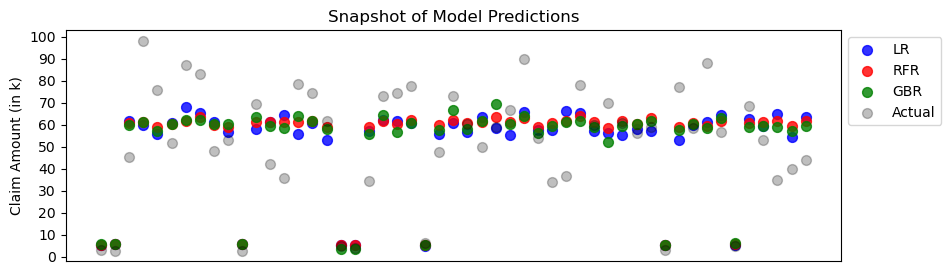

In [48]:
model_predictions = {
    'LR': (lr_results['y_pred'], 'blue', 0.8),
    'RFR': (rfr_results['y_pred'], 'red', 0.8),
    'GBR': (gbr_results['y_pred'], 'green', 0.8),
    'Actual': (y_test, 'black', 0.25)
}

plt.figure(figsize = (10, 3))

for key, value in model_predictions.items():
    plt.scatter(np.arange(0, len(y_test) - 149, 1), value[0][50:101], label = key, color = value[1], alpha = value[2], s = 50)

plt.yticks(np.arange(0, 110000, 10000), labels = np.arange(0, 110, 10))
plt.title('Snapshot of Model Predictions')
plt.ylabel('Claim Amount (in k)')
plt.xticks([])
    
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.show()

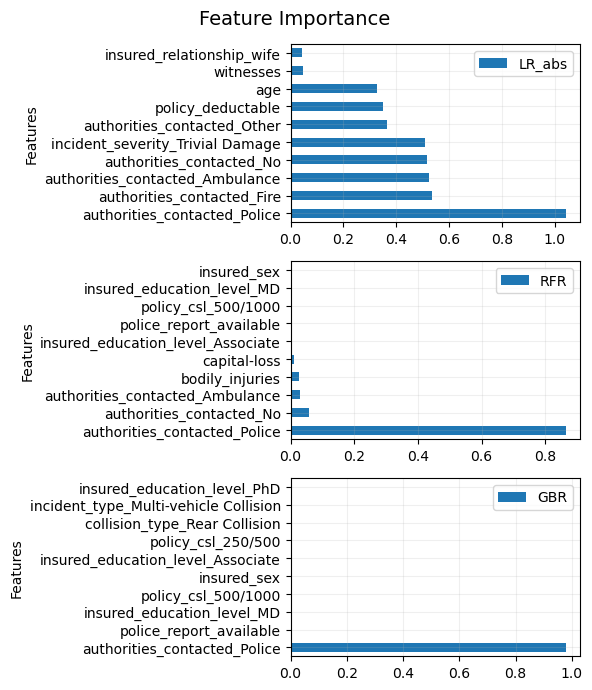

In [37]:
features_df = pd.DataFrame({'Features': x_train.columns, 
                            'LR': lr.regressor_.named_steps['model'].coef_,
                            'RFR': best_rfr.regressor_.named_steps['model'].feature_importances_,
                            'GBR': best_gbr.regressor_.named_steps['model'].feature_importances_})

features_df['LR_abs'] = features_df['LR'].abs()

fig, axes = plt.subplots(3, 1, figsize = (6, 7))
axes = axes.flatten()
plt.suptitle('Feature Importance', fontsize = 14)

features_df.sort_values('LR_abs', ascending = False).head(10).plot(x = 'Features', y = 'LR_abs', kind = 'barh', ax = axes[0])
features_df.sort_values('RFR', ascending = False).head(10).plot(x = 'Features', y = 'RFR', kind = 'barh', ax = axes[1])
features_df.sort_values('GBR', ascending = False).head(10).plot(x = 'Features', y = 'GBR', kind = 'barh', ax = axes[2])

for i in range(3):
    axes[i].grid(alpha = 0.2)

plt.tight_layout()
plt.show()